In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sequence.kernel.timeline import Timeline
from sequence.topology.optical_nodes import PolarizationAnalyzerNode
from sequence.topology.optical_nodes import SpdcSourceNode
from sequence.components.fiber_models import QuantumChannel, fiberQuantumChannel
from sequence.constants import SPEED_OF_LIGHT
from helpers import (
    sliding_windows_coincidences,
    reconstruct_rho_from_paulis,
    counts_to_probs,
    correlator_from_probs,
    plot_density_matrix_bars,
    curve_fit,
    cos2_model,
)
# Setup source
frequency = 1e6  # MHz####################
mean_photon_num = 0.01 # Mean photon number
bell_state = "psi-"  # Bell state
d1 = 1 # distance in m
d2 = 1 # distance in m
attenuation1 = 0  # Attenuation in dB/m for channel 1
attenuation2 = 0  # Attenuation in dB/m for channel 2

def analyze_windowed_coincidences(tags_A, tags_B, emmission_time=1, config= None):
    max_time_ps = emmission_time * 1e12
    time_integration_s = config.get("time_integration_ms", 1000) / 1000
    int_time_ps = time_integration_s * 1e12
    earliest_time = min(tags_A[0], tags_B[0]) if tags_A and tags_B else 0
    latest_time = earliest_time + max_time_ps

    coinc_list, CAR_list = [], []

    t = earliest_time
    while t < latest_time:
        win_A = [ts for ts in tags_A if t <= ts < t + int_time_ps]
        win_B = [ts for ts in tags_B if t <= ts < t + int_time_ps]
        result = sliding_windows_coincidences(config, np.array(win_A), np.array(win_B))
        coinc_list.append(result["coincidences_rate"])
        CAR_list.append(result["CAR"])    
        t += int_time_ps

    coinc_array = np.array(coinc_list)
    CAR_array = np.array(CAR_list)

    # --- Handle infinities ---
    if np.all(np.isinf(CAR_array)):
        CAR_mean, CAR_std = np.inf, 0.0
    else:
        # finite values only
        finite = CAR_array[np.isfinite(CAR_array)]
        if len(finite) == 0:  # all were NaN
            CAR_mean, CAR_std = np.nan, np.nan
        else:
            CAR_mean, CAR_std = finite.mean(), finite.std()

    return coinc_array.mean(), coinc_array.std(), CAR_mean, CAR_std

def measure_basis_pair(basisA, BasisB, emmission_time=1, config = None):
    end_time = (emmission_time * 1e12  + round(max(d1, d2) / SPEED_OF_LIGHT))#enough time for all photons to arrive
    tl = Timeline(stop_time = end_time)
    num_pulses = int(frequency * emmission_time)  # Total number of pulses
    source = SpdcSourceNode("source", tl, config={
        "wavelengths": [1557.36, 1558.17],
        "bandwidth": 2,
        "frequency": frequency,
        "mean_photon_num": mean_photon_num,
        "bell_state": bell_state,
    })

    # Two analyzers
    analyzer_A = PolarizationAnalyzerNode("analyzer_A", tl, config={"mode":"hwp_qwp"})
    analyzer_B = PolarizationAnalyzerNode("analyzer_B", tl, config={"mode":"hwp_qwp"})

    analyzer_A.set_basis(basisA)
    analyzer_B.set_basis(BasisB)

    # Quantum channels
    qc_A = QuantumChannel("qc_A", tl, attenuation=attenuation1, distance=d1)
    qc_B = QuantumChannel("qc_B", tl, attenuation=attenuation2, distance=d2)

    qc_A.set_ends(source, analyzer_A.name)
    qc_B.set_ends(source, analyzer_B.name)
    
    # Run
    tl.init()
    source.spdc.emit(num_pulses=num_pulses)
    tl.run()

    counts_A = analyzer_A.get_photon_times()
    counts_B = analyzer_B.get_photon_times()

    hh_mean, _, _, _ = analyze_windowed_coincidences(counts_A[0], counts_B[0], emmission_time, config)
    vv_mean, _, _, _ = analyze_windowed_coincidences(counts_A[1], counts_B[1], emmission_time, config)
    hv_mean, _, _, _ = analyze_windowed_coincidences(counts_A[0], counts_B[1], emmission_time, config)
    vh_mean, _, _, _ = analyze_windowed_coincidences(counts_A[1], counts_B[0], emmission_time, config)
    probs = counts_to_probs(hh_mean, hv_mean, vh_mean, vv_mean)

    return  probs, (hh_mean, hv_mean, vh_mean, vv_mean)

def emit_photons(angle_rad_A, angle_rad_B, emmission_time=1):
    """
    Emit photons and return detection counts for both analyzers.
    """
    end_time = emmission_time * 1e12  + round(max(d1, d2) / SPEED_OF_LIGHT) + 1e6#enough time for all photons to arrive
    tl = Timeline(stop_time = end_time)
    num_pulses = int(frequency * emmission_time)  # Total number of pulses
    source = SpdcSourceNode("source", tl, config={
        "wavelengths": [1557.36, 1558.17],
        "bandwidth": 2,
        "frequency": frequency,
        "mean_photon_num": mean_photon_num,
        "bell_state": bell_state,
    })

    # Two analyzers with configurable HWP angles
    analyzer_A = PolarizationAnalyzerNode("analyzer_A", tl, config={"mode":"hwp_only"})
    analyzer_B = PolarizationAnalyzerNode("analyzer_B", tl, config={"mode":"hwp_only"})

    analyzer_A.set_rotation_angle(angle_rad_A)
    analyzer_B.set_rotation_angle(angle_rad_B)    

    # # Quantum channels
    qc_A = QuantumChannel("qc_A", tl, distance=d1, attenuation=attenuation1)
    qc_B = QuantumChannel("qc_B", tl, distance=d2, attenuation=attenuation2)
    
    qc_A.set_ends(source, analyzer_A.name)
    qc_B.set_ends(source, analyzer_B.name)
    
    # Run
    tl.init()
    source.spdc.emit(num_pulses=num_pulses)
    tl.run()
    counts_A = analyzer_A.get_photon_times()
    counts_B = analyzer_B.get_photon_times()

    return counts_A, counts_B

def test_polarization_analyzer_coincidences(angle_rad_A, angle_rad_B, emmission_time=1, config=None): 
    """
    Test the polarization analyzer coincidences for two Bell states with configurable HWP angles.
    Args:
        angle_rad_A: Angle for polarizer A in radians
        angle_rad_B: Angle for polarizer B in radians
        emmission_time: Time duration for photon emission in seconds (default is 1 second)
    """
    
    counts_A, counts_B = emit_photons(angle_rad_A, angle_rad_B, emmission_time)
    
    hh_mean, hh_std, _, _ = analyze_windowed_coincidences(counts_A[0], counts_B[0], emmission_time, config)
    vv_mean, vv_std, _, _ = analyze_windowed_coincidences(counts_A[1], counts_B[1], emmission_time, config)
    hv_mean, hv_std, _, _ = analyze_windowed_coincidences(counts_A[0], counts_B[1], emmission_time, config)
    vh_mean, vh_std, _, _ = analyze_windowed_coincidences(counts_A[1], counts_B[0], emmission_time, config)
    #TO DO Use analyze_windowed_coincidences to calculate CAR as well It has mean and std

    return {
        "hh": (hh_mean, hh_std),
        "vv": (vv_mean, vv_std),
        "hv": (hv_mean, hv_std),
        "vh": (vh_mean, vh_std),
    }

def run_tomography(emmission_time=1.0, config=None):
    bases = ["Z","X","Y"]
    probs_by_pair = {}
    T2 = {}

    for A in bases:
        for B in bases:
            P, raw = measure_basis_pair(A, B, emmission_time, config)
            probs_by_pair[(A,B)] = P
            T2[(A,B)] = correlator_from_probs(P)

    # Build the 3×3 correlator map expected by the Pauli expansion
    Tmap = {(i,j): T2[(i,j)] for i in "XYZ" for j in "XYZ"}
    rho = reconstruct_rho_from_paulis(Tmap)  # singles ~ 0 for Bell states

    return rho, probs_by_pair, Tmap


    """
    Emit photons, compute histogram of time differences, extract CAR,
    and plot the coincidence histogram.

    Args:
        angle_rad_A (float): Polarizer A angle in radians
        angle_rad_B (float): Polarizer B angle in radians
        emmission_time (float): emission duration in seconds
        basis (str): which basis to analyze ("hh","vv","hv","vh")
    """

    # --- Step 1: simulate photon detections
    counts_A, counts_B = emit_photons(angle_rad_A, angle_rad_B, emmission_time)
    # choose which channel pair to analyze
    if basis == "hh":
        tags_A, tags_B = counts_A[0], counts_B[0]
    elif basis == "vv":
        tags_A, tags_B = counts_A[1], counts_B[1]
    elif basis == "hv":
        tags_A, tags_B = counts_A[0], counts_B[1]
    elif basis == "vh":
        tags_A, tags_B = counts_A[1], counts_B[0]
    else:
        raise ValueError("basis must be one of 'hh','vv','hv','vh'")

    # --- Step 2: compute coincidences and CAR
    res = sliding_windows_coincidences(config, np.array(tags_A), np.array(tags_B))

    histo = res["histo_vals"]
    edges = res["bin_edges"]
    centers = 0.5 * (edges[:-1] + edges[1:])

    CAR = res["CAR"]
    coincidences = res["coincidences_count"]
    accidentals = res["accidentals"]

    # --- Step 3: plot
    plt.figure(figsize=(8,5))
    plt.axvspan(res["window_low"], res["window_high"], color="red", alpha=0.3, label="Coincidence window")
    plt.bar(centers, histo, width=(edges[1]-edges[0]), alpha=0.7, label="Histogram")
    

    plt.xlabel("Time difference (ps)")
    plt.ylabel("Counts")
    plt.title(f"Coincidence histogram ({basis.upper()}), CAR={CAR:.2f}")
    plt.legend()
    plt.show()

    return {
        "CAR": CAR,
        "coincidences": coincidences,
        "accidentals": accidentals,
        "histogram": (centers, histo)
    }


def plot_coincidences_smooth(results, angles, coincidence_type="hh"):
    x = np.degrees(angles)

    for label, data in results.items():
        y_stats = data[coincidence_type]
        y_means = np.array([val[0] for val in y_stats])
        y_stds = np.array([val[1] for val in y_stats])

        # Plot raw data with error bars, save the color used
        line = plt.errorbar(
            x, y_means, yerr=y_stds, fmt='o', capsize=3,
            label=f"Polarizer A at {label}"
        )
        color = line[0].get_color()  # extract color from the points

        # Initial guess for fit parameters
        A0 = (y_means.max() - y_means.min()) / 2
        B0 = y_means.min()
        theta0_guess = 0
        p0 = [A0, theta0_guess, B0]

        try:
            popt, _ = curve_fit(cos2_model, x, y_means, p0=p0, maxfev=10000)
            x_fit = np.linspace(x.min(), x.max(), 500)
            y_fit = cos2_model(x_fit, *popt)

            # Plot smooth curve in the same color
            plt.plot(x_fit, y_fit, '-', color=color, linewidth=2)
        except RuntimeError:
            pass

    plt.xlabel("Polarizer B angle (degrees)")
    plt.ylabel(f"Coincidence Rate /s ({coincidence_type.upper()})")
    plt.title(f"Polarization Entanglement: {coincidence_type.upper()} Fringes")
    plt.grid(True)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()


emmission_time = 5 # seconds
time_integration=1
config = {
        "coincidence_window_width": 2000,  # in ps (depends on your resolution)
        "range_ns": 10,
        "time_bin":0.1, # in ns
        "time_integration_ms": time_integration * 1000,  # convert to ms
        "peak0": 0,  # adjust if you have a known delay between channels ps
    }

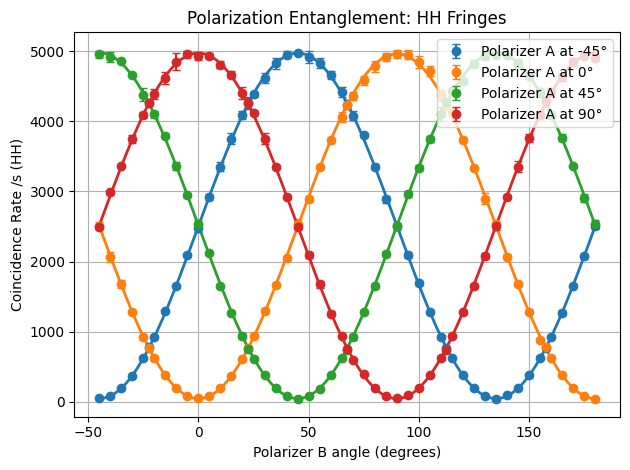

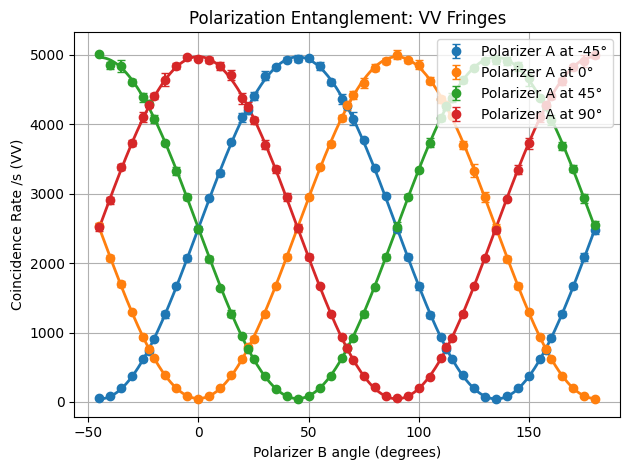

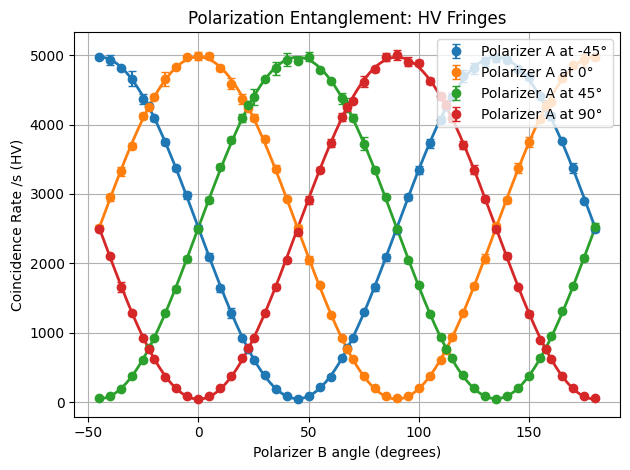

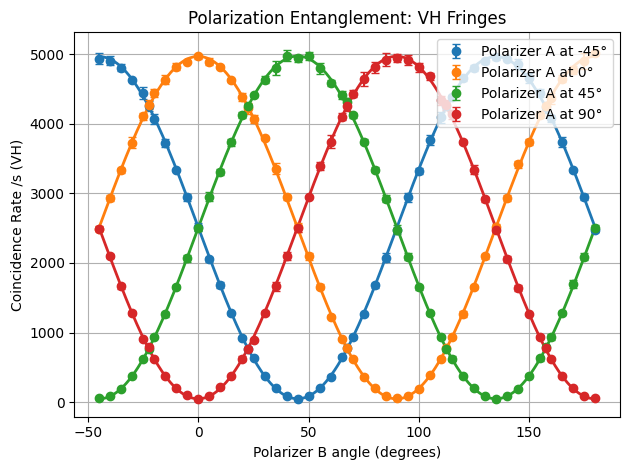

In [2]:
from math import radians
import numpy as np
from multiprocess.dummy import Pool 

angles = np.radians([
    -45, -40, -35, -30, -25, -22.5, -20, -15, -10, -5,
    0, 5, 10, 15, 20, 22.5, 25, 30, 35, 40, 45,
    50, 55, 60, 65, 67.5, 70, 75, 80, 85, 90,
    95, 100, 105, 110, 112.5, 115, 120, 125, 130,
    135, 140, 145, 150, 155, 157.5, 160, 165, 170, 175, 180
])

fixed_angles = [-45, 0, 45, 90]  # Alice fixed at these, Bob sweeps 'angles'

# Build jobs: fix Alice at 'fixed', sweep Bob over 'angles'
jobs = []
for fixed in fixed_angles:
    fixed_rad = radians(fixed)
    for angle in angles:
        jobs.append((fixed, fixed_rad, angle))

def run_job(args):
    fixed_deg, fixed_rad, bob_angle = args
    # Alice fixed (angle_rad_A=fixed_rad), Bob swept (angle_rad_B=bob_angle)
    stats = test_polarization_analyzer_coincidences(
        angle_rad_A=fixed_rad,
        angle_rad_B=bob_angle,
        emmission_time=emmission_time,
        config=config
    )
    return fixed_deg, np.degrees(bob_angle), stats

# Collect
raw_results = []
with Pool() as pool:
    for fixed_deg, bob_deg, stats in pool.imap_unordered(run_job, jobs):
        raw_results.append((fixed_deg, bob_deg, stats))

# Organize by Alice-fixed key; each holds Bob-sweep series
results = {f"{fixed}°": {"hh": [], "vv": [], "hv": [], "vh": []} for fixed in fixed_angles}

for fixed in fixed_angles:
    key = f"{fixed}°"
    # pick rows for this Alice angle and sort by Bob angle
    filtered = [(bdeg, s) for fdeg, bdeg, s in raw_results if fdeg == fixed]
    for _, stats in sorted(filtered, key=lambda x: x[0]):  # sort by Bob angle (deg)
        results[key]["hh"].append(stats["hh"])
        results[key]["vv"].append(stats["vv"])
        results[key]["hv"].append(stats["hv"])
        results[key]["vh"].append(stats["vh"])

plot_coincidences_smooth(results, angles, coincidence_type="hh")
plot_coincidences_smooth(results, angles, coincidence_type="vv")
plot_coincidences_smooth(results, angles, coincidence_type="hv")
plot_coincidences_smooth(results, angles, coincidence_type="vh")

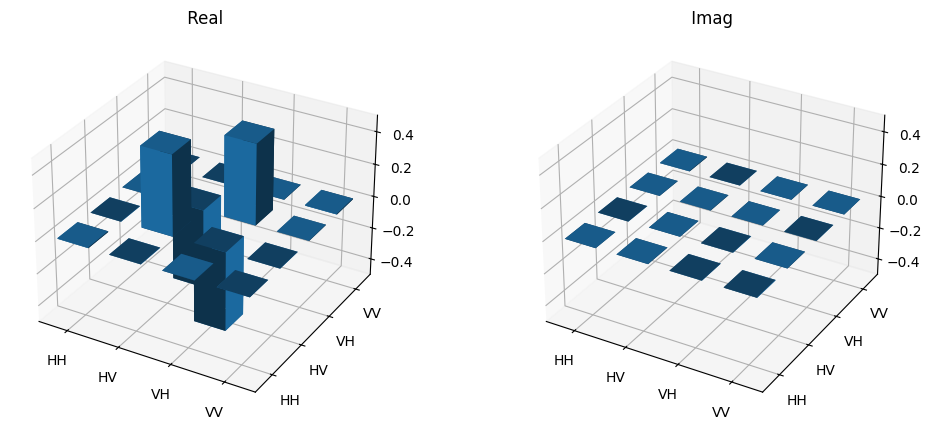

In [4]:
rho, probs, T = run_tomography(emmission_time=emmission_time, config=config)
plot_density_matrix_bars(rho, part="both", title_prefix="")

In [6]:
def get_bell_state(label="phi+"):
    """
    Return a 4x1 column vector for the chosen Bell state.
    label: "phi+", "phi-", "psi+", "psi-"
    """
    phi = np.zeros((4,1), dtype=complex)

    if label.lower() == "phi+":
        phi[0,0] = 1/np.sqrt(2)   # |HH>
        phi[3,0] = 1/np.sqrt(2)   # |VV>
    elif label.lower() == "phi-":
        phi[0,0] = 1/np.sqrt(2)
        phi[3,0] = -1/np.sqrt(2)
    elif label.lower() == "psi+":
        phi[1,0] = 1/np.sqrt(2)   # |HV>
        phi[2,0] = 1/np.sqrt(2)   # |VH>
    elif label.lower() == "psi-":
        phi[1,0] = 1/np.sqrt(2)
        phi[2,0] = -1/np.sqrt(2)
    else:
        raise ValueError("Unknown Bell state. Use 'phi+', 'phi-', 'psi+', 'psi-'.")

    return phi


def fidelity(rho, target):
    """
    Fidelity between density matrix rho and pure state target (vector).
    """
    target = target.reshape(-1,1)   # ensure column vector
    return float(np.real((target.conj().T @ rho @ target)[0,0]))


for label in ["phi+", "phi-", "psi+", "psi-"]:
    F = fidelity(rho, get_bell_state(label))
    print(f"Fidelity({label}): {F:.3f}")
rho

Fidelity(phi+): 0.005
Fidelity(phi-): 0.005
Fidelity(psi+): 0.006
Fidelity(psi-): 0.985


array([[ 4.71296461e-03+0.00000000e+00j, -1.55732141e-03-6.97189174e-04j,
         8.67813111e-04+7.88927059e-04j, -1.28598204e-05+2.95517631e-03j],
       [-1.55732141e-03+6.97189174e-04j,  4.95287035e-01+0.00000000e+00j,
        -4.89688110e-01+1.61400124e-03j, -8.67813111e-04-7.88927059e-04j],
       [ 8.67813111e-04-7.88927059e-04j, -4.89688110e-01-1.61400124e-03j,
         4.95287035e-01-2.77555756e-17j,  1.55732141e-03+6.97189174e-04j],
       [-1.28598204e-05-2.95517631e-03j, -8.67813111e-04+7.88927059e-04j,
         1.55732141e-03-6.97189174e-04j,  4.71296461e-03+6.77626358e-21j]])